In [4]:
import ipaddress
import pandas as pd
import matplotlib.pyplot as plt

# Keep consistent with other analysis notebooks
TIME_OFFSET = 10800

In [11]:
def plot_mean_mbtcp_minus_byte_cnt_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    mbtcp_len_col="mbtcp.len",
    byte_cnt_col="modbus.byte_cnt",
    time_offset_seconds=TIME_OFFSET,
):
    """
    1) Plot mean(mbtcp.len - modbus.byte_cnt) per src IP in 1-second bins for
    [center_timestamp - interval_seconds, center_timestamp + interval_seconds].
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", mbtcp_len_col, byte_cnt_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")

    df[mbtcp_len_col] = pd.to_numeric(df[mbtcp_len_col], errors="coerce")
    df[byte_cnt_col] = pd.to_numeric(df[byte_cnt_col], errors="coerce")
    df = df[df["modbus.func_code"].notna()].copy()
    df["len_minus_byte_cnt"] = df[mbtcp_len_col] - df[byte_cnt_col]
    print(df["mbtcp.len"].dtype)
    print(df["mbtcp.len"].head(10))

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")["len_minus_byte_cnt"].mean().reindex(bins)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("mean(mbtcp.len - modbus.byte_cnt)")
    plt.title(f"Mean (mbtcp.len - modbus.byte_cnt) for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return series


def plot_sum_is_mismatch_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    mbtcp_len_col="mbtcp.len",
    byte_cnt_col="modbus.byte_cnt",
    time_offset_seconds=TIME_OFFSET,
):
    """
    2) Plot sum(is_mismatch) per src IP in 1-second bins.

    is_mismatch is defined as 1 when mbtcp.len != modbus.byte_cnt and both are present,
    otherwise 0.
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", mbtcp_len_col, byte_cnt_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")

    df[mbtcp_len_col] = pd.to_numeric(df[mbtcp_len_col], errors="coerce")
    df[byte_cnt_col] = pd.to_numeric(df[byte_cnt_col], errors="coerce")

    valid = df[mbtcp_len_col].notna() & df[byte_cnt_col].notna()
    mismatch = valid & (df[mbtcp_len_col] != df[byte_cnt_col])
    df["is_mismatch"] = mismatch.astype(int)

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")["is_mismatch"].sum().reindex(bins, fill_value=0)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("sum(is_mismatch)")
    plt.title(f"Sum of is_mismatch for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return series


def plot_nunique_func_code_per_src_ip(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    func_col="modbus.func_code",
    time_offset_seconds=TIME_OFFSET,
):
    """
    3) Plot nunique(modbus.func_code) per src IP in 1-second bins.
    """
    ipaddress.ip_address(src_ip)
    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "frame.time_epoch", func_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")[func_col].nunique().reindex(bins, fill_value=0)

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel(f"nunique({func_col})")
    plt.title(f"Unique function codes for src={src_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return series


# Example usage:
# input_csv = "../train/cscada_attack_ssw.csv"
# src_ip = "185.175.0.5"
# center_timestamp = "2023-03-19 03:01:57.813"
# x = 20
#
# plot_mean_mbtcp_minus_byte_cnt_per_src_ip(input_csv, src_ip, center_timestamp, x)
# plot_sum_is_mismatch_per_src_ip(input_csv, src_ip, center_timestamp, x)
# plot_nunique_func_code_per_src_ip(input_csv, src_ip, center_timestamp, x)

/tmp/ipykernel_298019/4058737216.py:15: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


float64
6     6.0
8     4.0
16    6.0
23    6.0
25    5.0
31    6.0
35    5.0
42    6.0
44    4.0
51    6.0
Name: mbtcp.len, dtype: float64


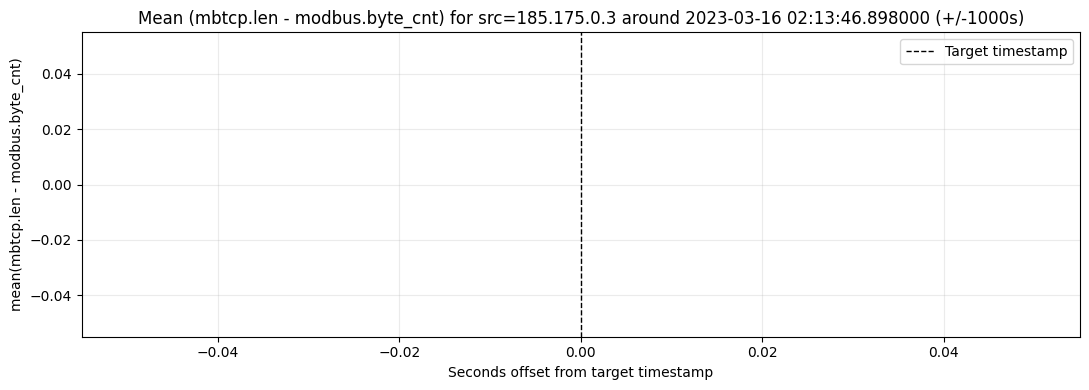

/tmp/ipykernel_298019/4058737216.py:15: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


float64
6     6.0
8     4.0
16    6.0
23    6.0
25    5.0
31    6.0
35    5.0
42    6.0
44    4.0
51    6.0
Name: mbtcp.len, dtype: float64


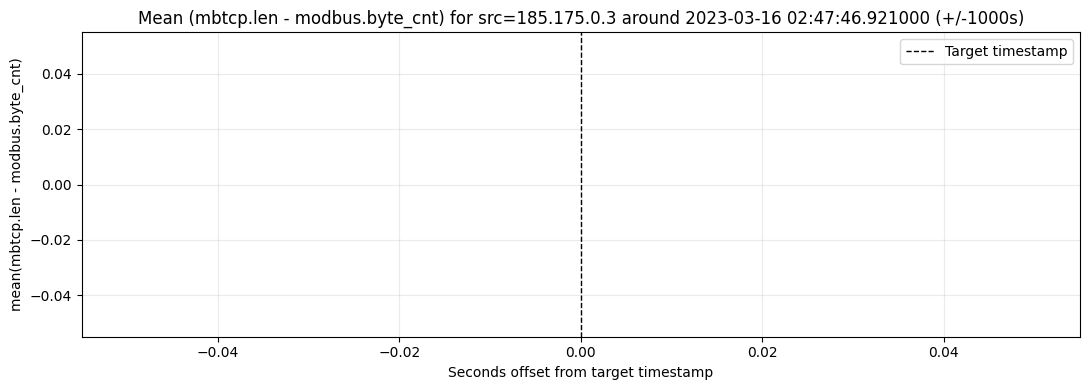

/tmp/ipykernel_298019/4058737216.py:15: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


float64
6     6.0
8     4.0
16    6.0
23    6.0
25    5.0
31    6.0
35    5.0
42    6.0
44    4.0
51    6.0
Name: mbtcp.len, dtype: float64


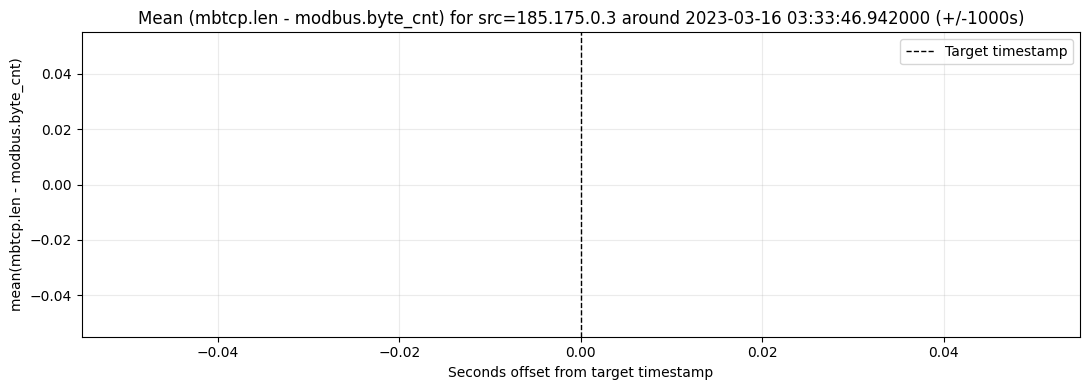

/tmp/ipykernel_298019/4058737216.py:15: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


float64
6     6.0
8     4.0
16    6.0
23    6.0
25    5.0
31    6.0
35    5.0
42    6.0
44    4.0
51    6.0
Name: mbtcp.len, dtype: float64


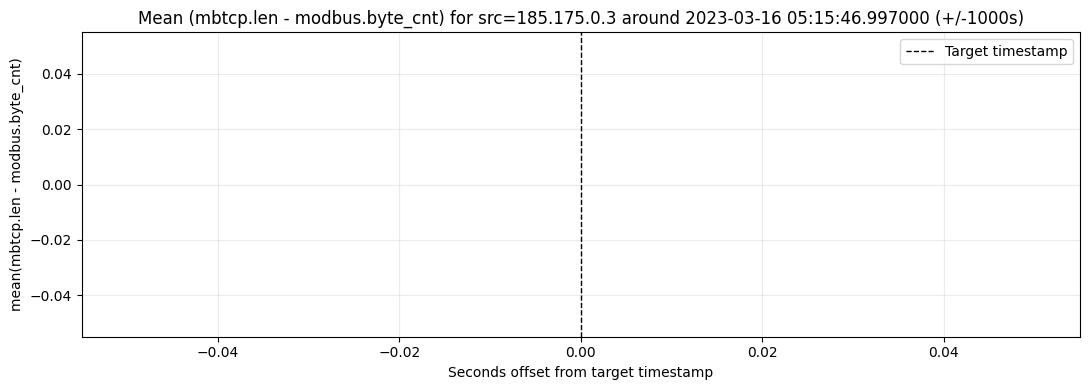

2023-03-16 04:59:06   NaN
2023-03-16 04:59:07   NaN
2023-03-16 04:59:08   NaN
2023-03-16 04:59:09   NaN
2023-03-16 04:59:10   NaN
                       ..
2023-03-16 05:32:22   NaN
2023-03-16 05:32:23   NaN
2023-03-16 05:32:24   NaN
2023-03-16 05:32:25   NaN
2023-03-16 05:32:26   NaN
Freq: s, Name: len_minus_byte_cnt, Length: 2001, dtype: float64

In [12]:
plot_mean_mbtcp_minus_byte_cnt_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 02:13:46.898", 1000)
plot_mean_mbtcp_minus_byte_cnt_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 02:47:46.921", 1000)
plot_mean_mbtcp_minus_byte_cnt_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 03:33:46.942", 1000)
plot_mean_mbtcp_minus_byte_cnt_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 05:15:46.997", 1000)

/tmp/ipykernel_298019/2735254570.py:78: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


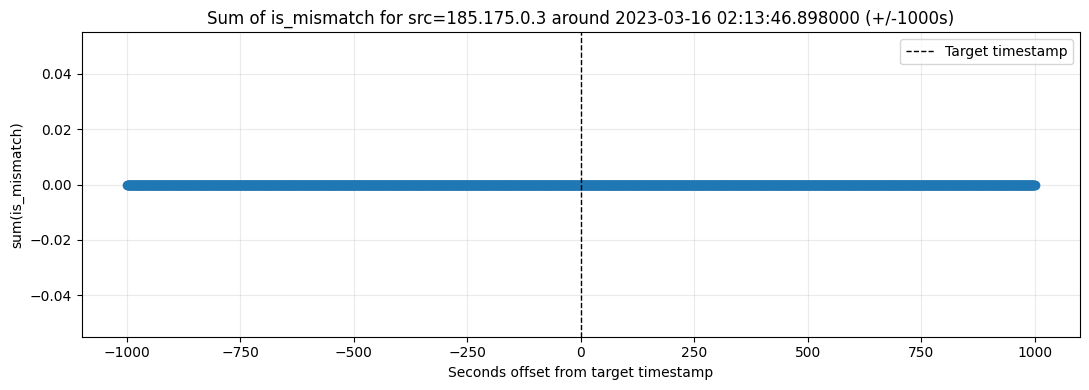

/tmp/ipykernel_298019/2735254570.py:78: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


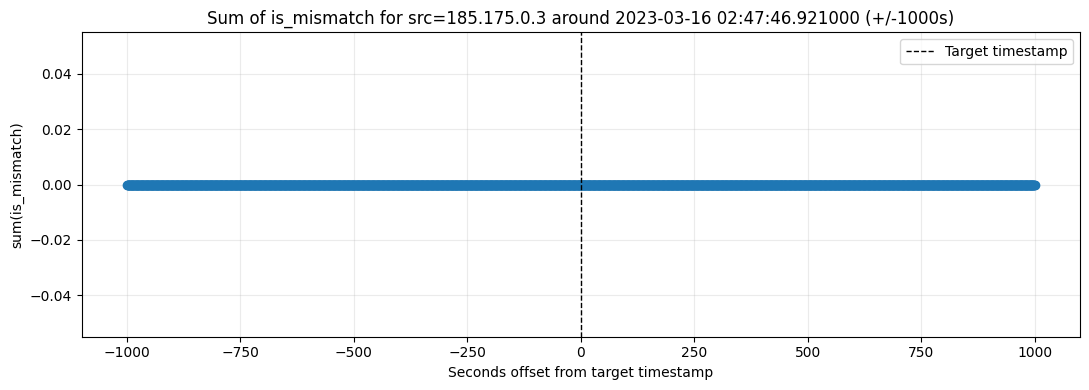

/tmp/ipykernel_298019/2735254570.py:78: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


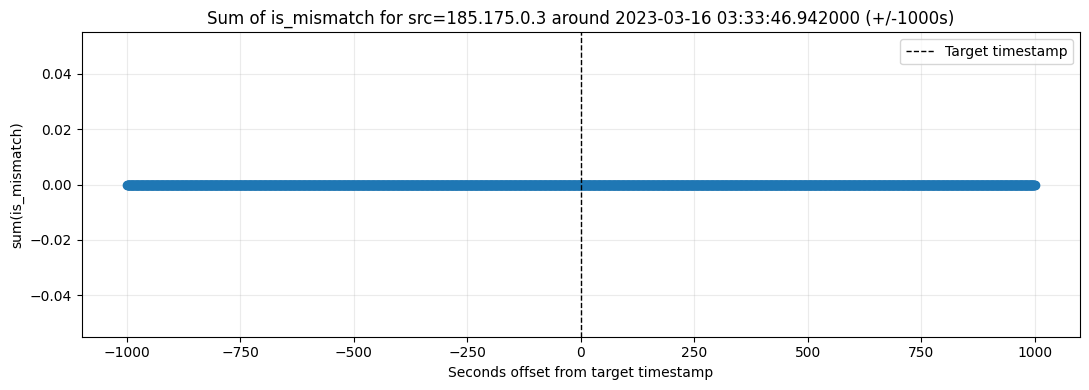

/tmp/ipykernel_298019/2735254570.py:78: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


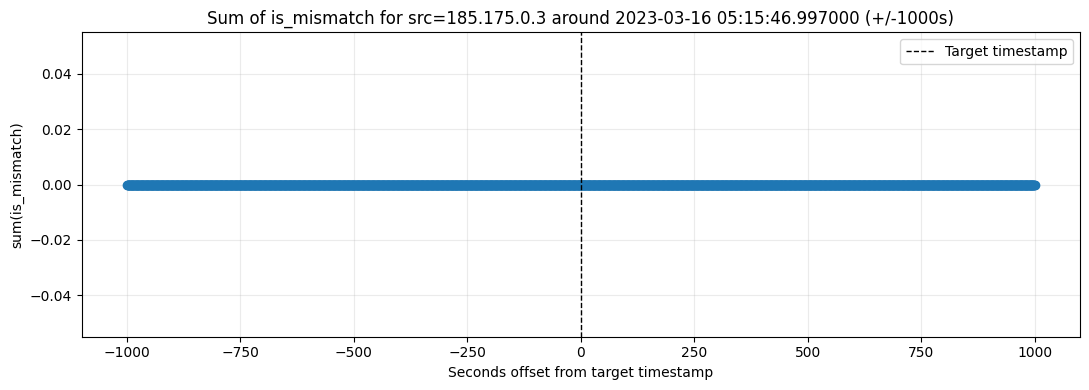

2023-03-16 04:59:06    0
2023-03-16 04:59:07    0
2023-03-16 04:59:08    0
2023-03-16 04:59:09    0
2023-03-16 04:59:10    0
                      ..
2023-03-16 05:32:22    0
2023-03-16 05:32:23    0
2023-03-16 05:32:24    0
2023-03-16 05:32:25    0
2023-03-16 05:32:26    0
Freq: s, Name: is_mismatch, Length: 2001, dtype: int64

In [7]:
plot_sum_is_mismatch_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 02:13:46.898", 1000)
plot_sum_is_mismatch_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 02:47:46.921", 1000)
plot_sum_is_mismatch_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 03:33:46.942", 1000)
plot_sum_is_mismatch_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 05:15:46.997", 1000)

/tmp/ipykernel_298019/2735254570.py:140: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


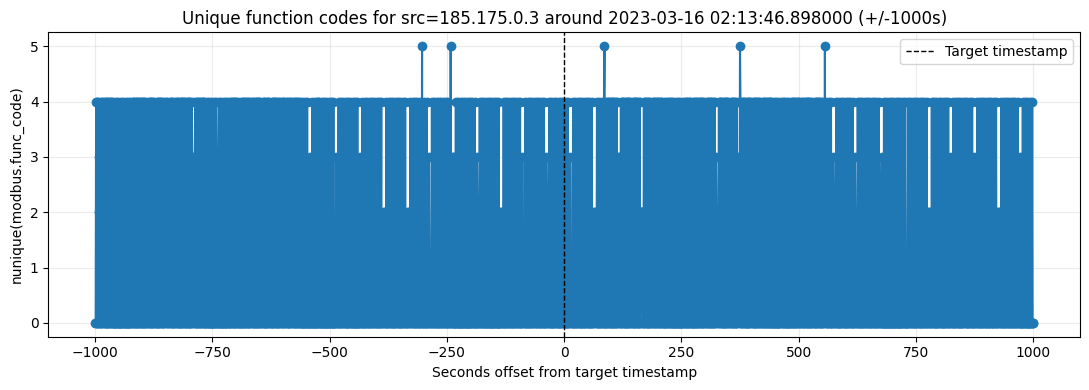

/tmp/ipykernel_298019/2735254570.py:140: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


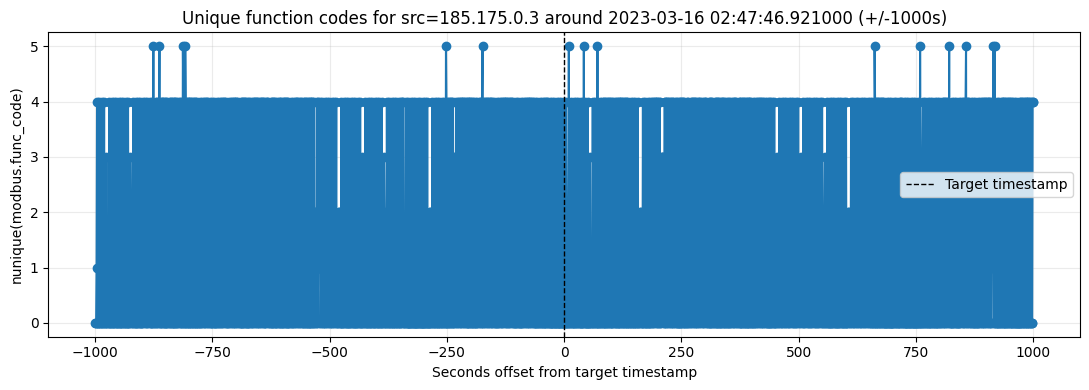

/tmp/ipykernel_298019/2735254570.py:140: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


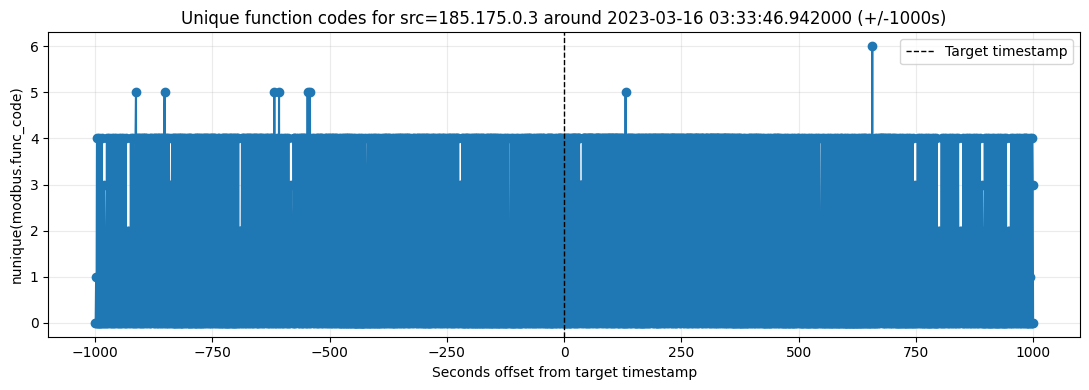

/tmp/ipykernel_298019/2735254570.py:140: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.byte_cnt, 10: modbus.bit_cnt, 11: modbus.regval_uint16, 12: modbus.data, 13: modbus.response_time, 14: modbus.request_frame) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


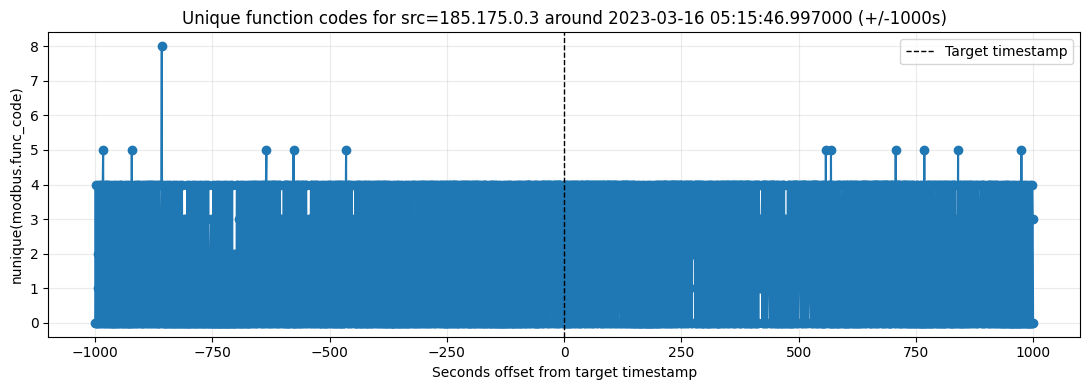

2023-03-16 04:59:06    0
2023-03-16 04:59:07    4
2023-03-16 04:59:08    0
2023-03-16 04:59:09    0
2023-03-16 04:59:10    0
                      ..
2023-03-16 05:32:22    0
2023-03-16 05:32:23    0
2023-03-16 05:32:24    4
2023-03-16 05:32:25    3
2023-03-16 05:32:26    0
Freq: s, Name: modbus.func_code, Length: 2001, dtype: int64

In [8]:
plot_nunique_func_code_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 02:13:46.898", 1000)
plot_nunique_func_code_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 02:47:46.921", 1000)
plot_nunique_func_code_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 03:33:46.942", 1000)
plot_nunique_func_code_per_src_ip("../train/chunks/csc_1.csv", "185.175.0.3", "2023-03-16 05:15:46.997", 1000)